In [29]:
from sklearn.datasets import fetch_openml
import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import torch
from sklearn.base import BaseEstimator
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier

mnist = fetch_openml("mnist_784", version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [30]:
X, y = mnist["data"], mnist["target"]
print(torch.cuda.is_available())

False


<class 'numpy.ndarray'>


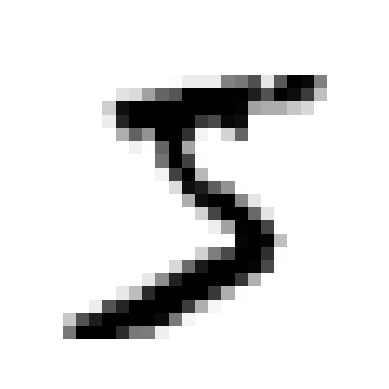

In [31]:
if (type(X) != "numpy.ndarray"):
    X = X.to_numpy()
print(type(X))
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=mpl.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()

In [32]:
y[0]

'5'

In [33]:
y = y.astype(np.uint8)

In [34]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [35]:
y_train_5 = y_train == 5
y_test_5 = y_test == 5
print(np.unique(y_test_5))

[False  True]


In [36]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [37]:
sgd_clf.predict([some_digit])

array([ True])

### Implementing Cross-Validation

In [38]:
skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
for train_idx, test_idx in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_idx]
    y_train_folds = y_train_5[train_idx]
    X_test_folds = X_train[test_idx]
    y_test_folds = y_train_5[test_idx]
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct / len(y_pred))

0.9669
0.91625
0.96785


In [39]:
scores = cross_val_score(sgd_clf, X_train, y_train_5, cv=3)

print(scores)
print(scores.mean())

[0.95035 0.96035 0.9604 ]
0.9570333333333334


In [40]:
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)


never_5_clf = Never5Classifier()
y_train_pred = cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

### Implementing Confusion Matrix

In [41]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)


confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [42]:
print(y_train_5.shape)
print(y_train_pred.shape)

(60000,)
(60000,)


In [43]:
y_train_perfect_prediction = y_train_5
confusion_matrix(y_train_5, y_train_perfect_prediction)

array([[54579,     0],
       [    0,  5421]])

In [44]:
from sklearn.metrics import precision_score,recall_score
precision = precision_score(y_train_5,y_train_pred)

In [45]:
recall = recall_score(y_train_5,y_train_pred)

In [46]:
f1 = (2*precision*recall)/(precision+recall)
print(f1)

0.7325171197343846


In [47]:
from sklearn.metrics import f1_score

f1_score(y_train_5,y_train_pred)

0.7325171197343847

In [48]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [49]:
threshold = 8000
y_some_digit_pred = y_scores > threshold
y_some_digit_pred

array([False])

In [50]:
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)

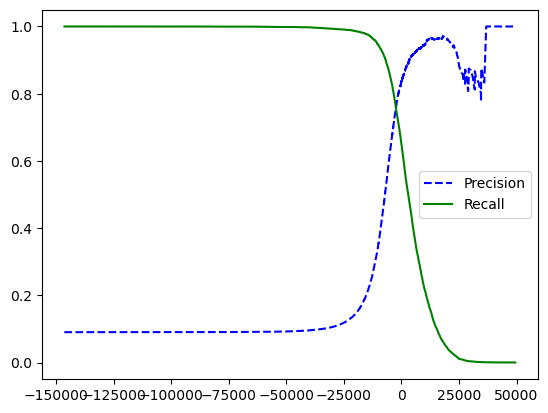

In [51]:
from sklearn.metrics import precision_recall_curve

precision, recall, threshold = precision_recall_curve(y_train_5, y_scores)


def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    [...]  # highlight the threshold, add the legend, axis label and grid


plot_precision_recall_vs_threshold(precision, recall, threshold)

plt.legend()
plt.show()

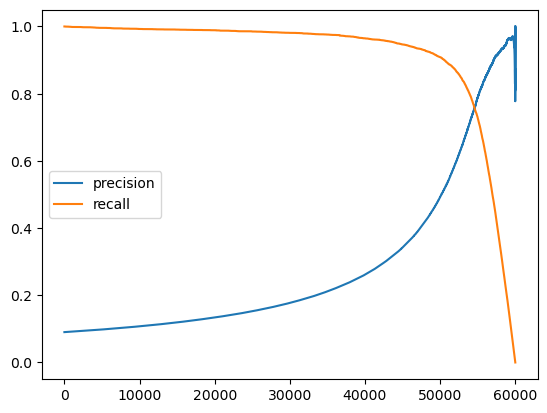

In [52]:
plt.plot(precision, label="precision")
plt.plot(recall,label="recall")
plt.legend()
plt.show()


C:\Users\Haji Suleman\AppData\Local\Temp\ipykernel_16724\4082079554.py:4: MatplotlibDeprecationWarning: Passing label as a length 3908 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(fpr, tpr, linewidth=2, label=label)


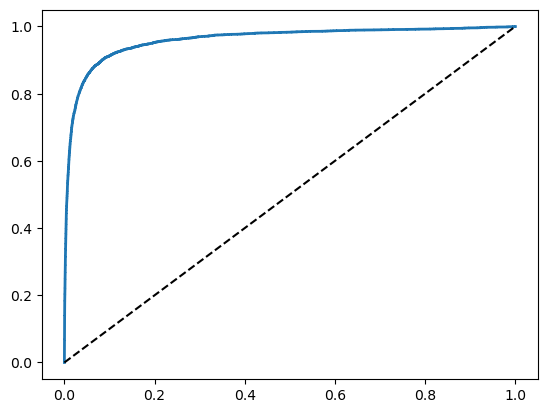

In [53]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds = roc_curve(y_train_5,y_scores)
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    [...] # Add axis labels and grid
plot_roc_curve(fpr,tpr,thresholds)

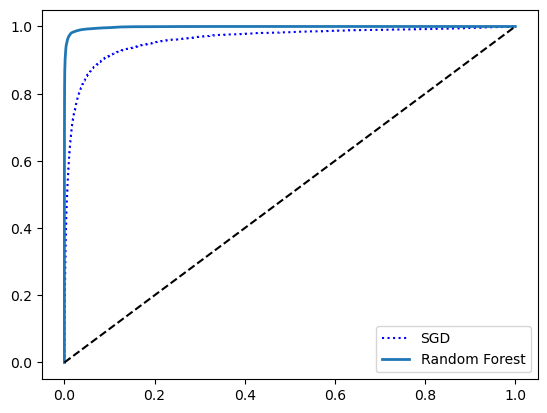

In [54]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(
    forest_clf, X_train, y_train_5, cv=3, method="predict_proba"
)
y_scores_forest = y_probas_forest[:, 1]  # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

In [55]:
some_digit_scores = sgd_clf.decision_function([some_digit])

In [57]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train,y_train)

OneVsOneClassifier(estimator=SGDClassifier(random_state=42))

In [58]:
ovo_clf.predict([some_digit])

array([5], dtype=uint8)

In [59]:
len(ovo_clf.estimators_)

45

In [60]:
forest_clf.fit(X_train,y_train)
forest_clf.predict([some_digit])

array([5], dtype=uint8)

In [61]:
forest_clf.predict_proba([some_digit])

array([[0.  , 0.  , 0.01, 0.08, 0.  , 0.9 , 0.  , 0.  , 0.  , 0.01]])

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")


array([0.87365, 0.85835, 0.8689 ])

In [66]:
y_train_pred = cross_val_predict(sgd_clf,X_train,y_train,cv=3)

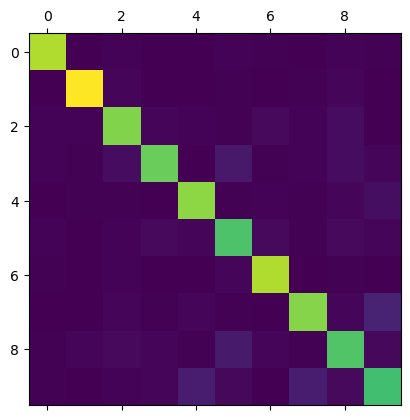

In [67]:
conf_mx = confusion_matrix(y_train,y_train_pred)
plt.matshow(conf_mx)
plt.show()

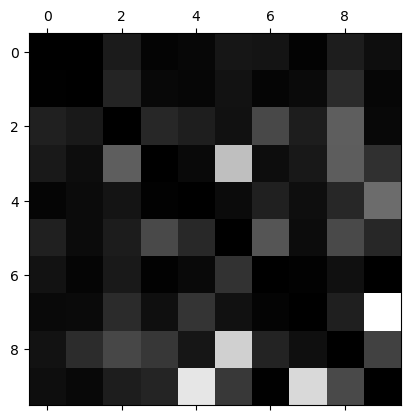

In [69]:
row_sums = conf_mx.sum(axis=1,keepdims=True)
norm_conf_mx = conf_mx/row_sums
np.fill_diagonal(norm_conf_mx,0)
plt.matshow(norm_conf_mx,cmap=plt.cm.gray)
plt.show()

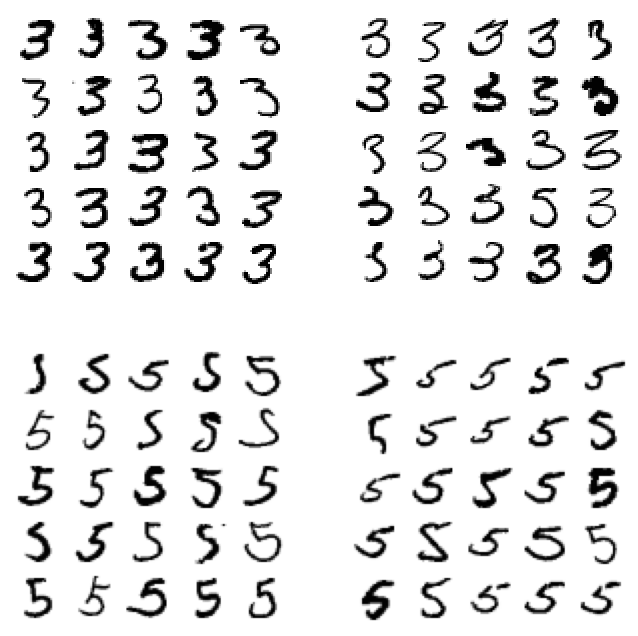

In [74]:
def plot_digits(instances, images_per_row=5):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size, size) for instance in instances]
    n_rows = (len(images) - 1) // images_per_row + 1
    row_images = []
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        if len(rimages) < images_per_row:
            rimages += [np.zeros((size, size))] * (images_per_row - len(rimages))
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

cl_a, cl_b = 3, 5
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

plt.figure(figsize=(8, 8))

plt.subplot(221)
plot_digits(X_aa[:25], images_per_row=5)

plt.subplot(222)
plot_digits(X_ab[:25], images_per_row=5)

plt.subplot(223)
plot_digits(X_ba[:25], images_per_row=5)

plt.subplot(224)
plot_digits(X_bb[:25], images_per_row=5)

plt.show()

In [79]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = y_train >= 7
y_train_odd = y_train % 2 == 1
y_multilabels = np.c_[y_train_large,y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train,y_multilabels)

KNeighborsClassifier()

In [80]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [81]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabels, cv=3)
f1_score(y_multilabels,y_train_knn_pred,average="macro")

0.9764102655606048

In [ ]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[1]])
plot_digits(X_test_mod)
plt.show()
plot_digits(clean_digit)